In [43]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt


## SABR model
$$\begin{cases}
dF(t) = F(t)^\beta \alpha(t) dW_1(t) \\
d\alpha(t) = \mu \alpha(t) dW_2(t)
\end{cases}, \ \
d\langle W_1, W_2 \rangle_t = \rho dt
$$

We apply the Homotopy Analysis Method to compute the approximate price of the call with payoff $(F-K)_+$.

In [44]:
# Parameters
beta = 0.2
rho = 0.0
nu = 0.3
T = 30
gamma = 0.05

alpha = 0.005
F = 0.01

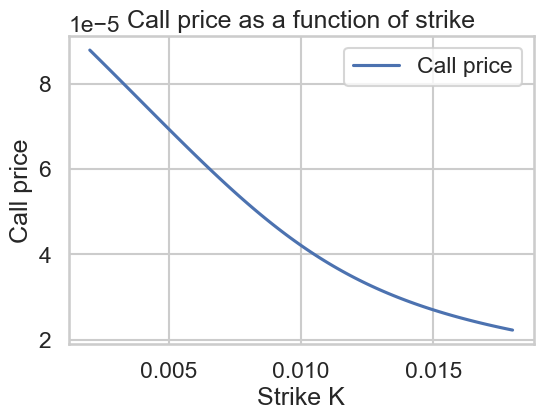

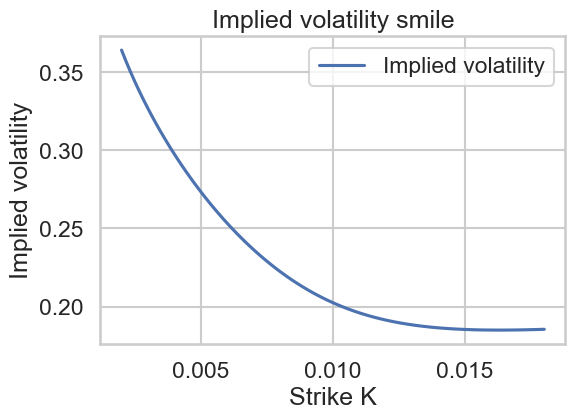

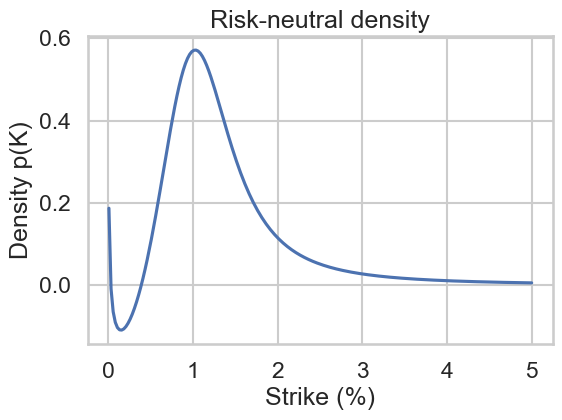

In [45]:
def V_0(F,alpha,t,K):
    G1 = F-K
    G2 = F+K
    dq = (K**(1-beta)-F**(1-beta)) / (1-beta)
    v_min = np.sqrt(dq**2 * nu**2 + 2*rho*dq*nu*alpha + alpha**2)
    s_min = np.abs(np.log((v_min+rho*alpha+dq*nu)/((1+rho)*alpha)))
    b0 = nu * np.abs(G1) / s_min
    d1 = G1 / (b0 * np.sqrt(t))
    d2 = -G2 / (b0 * np.sqrt(t))
    G3 = b0*np.sqrt(t)*(np.exp(-d1**2/2)-np.exp(-d2**2/2))/np.sqrt(2*np.pi)
    return G1*norm.cdf(d1) + G2*norm.cdf(d2) + G3

def C(F,alpha,K):
    return F*V_0(F,alpha,T,K)

def p(F,alpha,K):
    eps = 1e-6
    return (C(F,alpha,K+eps) - 2*C(F,alpha,K) + C(F,alpha,K-eps)) / eps**2

def BS_call(F,K,T,sigma):

    d1 = (np.log(F/K) + 0.5*sigma**2*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    return F*norm.cdf(d1) - K*norm.cdf(d2)

def implied_vol(F,alpha,K):

    price = C(F,alpha,K) / F

    f = lambda sigma: BS_call(F,K,T,sigma) - price

    a = 1e-8
    b = 5

    fa = f(a)
    fb = f(b)

    if fa*fb > 0:
        return np.nan 

    return brentq(f,a,b)

Ks = np.linspace(0.002,0.018,100)

prices = [C(F,alpha,K) for K in Ks]

plt.figure(figsize=(6,4))
plt.plot(Ks, prices, label="Call price")

plt.xlabel("Strike K")
plt.ylabel("Call price")
plt.title("Call price as a function of strike")

plt.legend()
plt.grid(True)

plt.show()

vols = [implied_vol(F,alpha,K) for K in Ks]

plt.figure(figsize=(6,4))
plt.plot(Ks, vols, label="Implied volatility")
plt.xlabel("Strike K")
plt.ylabel("Implied volatility")
plt.title("Implied volatility smile")
plt.legend()
plt.grid(True)

plt.show()

Ks_dens = np.linspace(0.0001,0.05,200)

dens = [p(F,alpha,K) for K in Ks_dens]

plt.figure(figsize=(6,4))
plt.plot(Ks_dens*100, dens)
plt.xlabel("Strike (%)")
plt.ylabel("Density p(K)")
plt.title("Risk-neutral density")
plt.grid(True)

plt.show()

## References
[1] Homotopy Analysis Method Applied to SABR and XVA, Sakuma, 2019, Wilmott